# 01 — Exploratory Data Analysis (ARMD)

Look at the tables **before** building the graph: shapes, columns, null rates, and — most importantly — the susceptibility (S/I/R) label balance and the ward distribution (our partitioning axis).

This notebook only *looks*. All graph/model logic goes in `src/amr_fed/` modules later.


## Setup (works locally and on Colab)

In [ ]:
import sys, os
from pathlib import Path

REPO = "Capstone-amr-fed"
REPO_URL = "https://github.com/RawEgg6/Capstone-amr-fed.git"

if "google.colab" in sys.modules:
    if not Path(REPO).exists():
        !git clone {REPO_URL}
    %cd {REPO}
    !pip install -q torch-geometric "flwr[simulation]" pyarrow
    from google.colab import drive
    drive.mount("/content/drive")
    os.environ["ARMD_DIR"] = "/content/drive/MyDrive/ARMD"   # match your Drive shortcut name

src = Path.cwd() / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

import pandas as pd
import matplotlib.pyplot as plt
from amr_fed import config
pd.set_option("display.max_columns", 60)
print("Data dir:", config.DATA_DIR)

Data dir: /Users/vsharma4/Library/CloudStorage/GoogleDrive-vsharma4@g2.com/.shortcut-targets-by-id/1uVx5PmldPyJBMtnB9Lkl9N1rNBQrmJt-/ARMD


## Load the tables we need (skips any that are missing)

In [13]:
tables = {}
for key, fname in config.ARMD_TABLES.items():
    path = config.DATA_DIR / fname
    if not path.exists():
        print(f"MISSING {key}")
        continue
    nrows = 100_000 if key == "comorbidity" else None   # sample while it syncs
    tables[key] = pd.read_csv(path, low_memory=False, nrows=nrows)
    print(f"loaded {key:14s} {tables[key].shape}")

loaded cohort         (2241050, 10)
loaded demographics   (751075, 5)
loaded adi            (751075, 6)
loaded comorbidity    (100000, 7)
loaded procedures     (1664615, 6)
loaded ward           (751075, 8)
loaded labs           (1408677, 59)
loaded vitals         (4591374, 28)
loaded abx_class_exp  (5402486, 8)
loaded resistance     (2161648, 7)


## Per-table overview

Shape, null rates, and a peek at columns for each table.

In [15]:
def summarize(name, df):
    print("="*70)
    print(f"{name}   rows={len(df):,}  cols={df.shape[1]}  mem={df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    nulls = (df.isna().mean()*100).round(1)
    top_null = nulls[nulls > 0].sort_values(ascending=False).head(8)
    if len(top_null):
        print("highest null %:")
        print(top_null.to_string())
    else:
        print("no nulls")
    print("columns:", list(df.columns))

for name, df in tables.items():
    summarize(name, df)

cohort   rows=2,241,050  cols=10  mem=365.0 MB
no nulls
columns: ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility']
demographics   rows=751,075  cols=5  mem=45.5 MB
no nulls
columns: ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'age', 'gender']
adi   rows=751,075  cols=6  mem=64.0 MB
no nulls
columns: ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'adi_score', 'adi_state_rank']
comorbidity   rows=100,000  cols=7  mem=12.1 MB
highest null %:
comorbidity_component_end_days_culture    98.2
columns: ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'comorbidity_component', 'comorbidity_component_start_days_culture', 'comorbidity_component_end_days_culture']
procedures   rows=1,664,615  cols=6  mem=156.4 MB
no nulls
columns: ['anon_id', 'pat_enc_csn_id_coded', 'order_pro

## The target: susceptibility label balance (cohort)

This is what we predict on the organism→antibiotic edge. Class imbalance here drives the loss weighting in the model.


--- susceptibility ---
susceptibility
Susceptible     1289258
Null             634468
Resistant        265071
Intermediate      47651
Inconclusive       2670
Synergism          1932
Name: count, dtype: int64

--- was_positive ---
was_positive
1    1610252
0     630798
Name: count, dtype: int64

--- culture_description ---
culture_description
URINE          1516950
BLOOD           435774
RESPIRATORY     288326
Name: count, dtype: int64


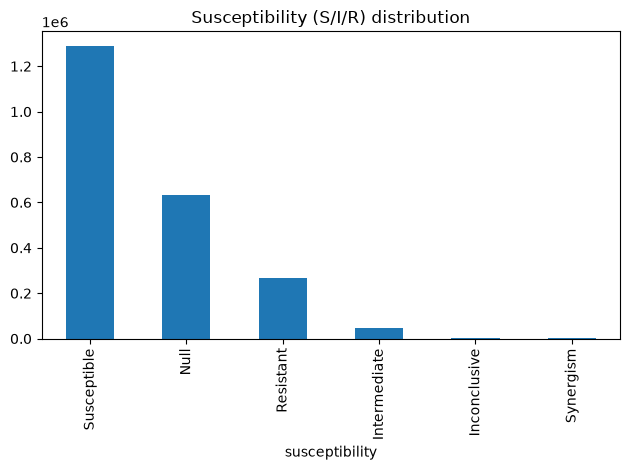

In [8]:
cohort = tables["cohort"]

for col in ["susceptibility", "was_positive", "culture_description"]:
    if col in cohort.columns:
        print(f"\n--- {col} ---")
        print(cohort[col].value_counts(dropna=False).head(15))

if "susceptibility" in cohort.columns:
    cohort["susceptibility"].value_counts().plot(kind="bar", title="Susceptibility (S/I/R) distribution")
    plt.tight_layout(); plt.show()

## Organism & antibiotic cardinality (future node counts)

In [9]:
for col in ["organism", "antibiotic"]:
    if col in cohort.columns:
        print(f"{col}: {cohort[col].nunique()} distinct")
        print(cohort[col].value_counts().head(10), "\n")

organism: 315 distinct
organism
ESCHERICHIA COLI                 874897
Null                             632308
KLEBSIELLA PNEUMONIAE            151964
STAPHYLOCOCCUS AUREUS             82519
PROTEUS MIRABILIS                 67938
ENTEROCOCCUS SPECIES              64511
PSEUDOMONAS AERUGINOSA            48959
MUCOID PSEUDOMONAS AERUGINOSA     33037
KLEBSIELLA OXYTOCA                25066
ENTEROBACTER CLOACAE COMPLEX      24042
Name: count, dtype: int64 

antibiotic: 55 distinct
antibiotic
Null                             632308
Ciprofloxacin                    111321
Gentamicin                       105570
Levofloxacin                     104465
Trimethoprim/Sulfamethoxazole    103276
Ampicillin                        93613
Nitrofurantoin                    90589
Piperacillin/Tazobactam           86436
Cefazolin                         83221
Ceftriaxone                       71520
Name: count, dtype: int64 



## Ward distribution — the partitioning axis

We simulate hospitals by ward (ICU / ER / IP / OP). Check how much data each ward has — uneven sizes are fine and realistic, but a ward with too few rows can't train a useful local model.

ward flag columns: ['hosp_ward_IP', 'hosp_ward_OP', 'hosp_ward_ER', 'hosp_ward_ICU']
hosp_ward_IP: 464,113 positive
hosp_ward_OP: 275,304 positive
hosp_ward_ER: 290,229 positive
hosp_ward_ICU: 50,613 positive


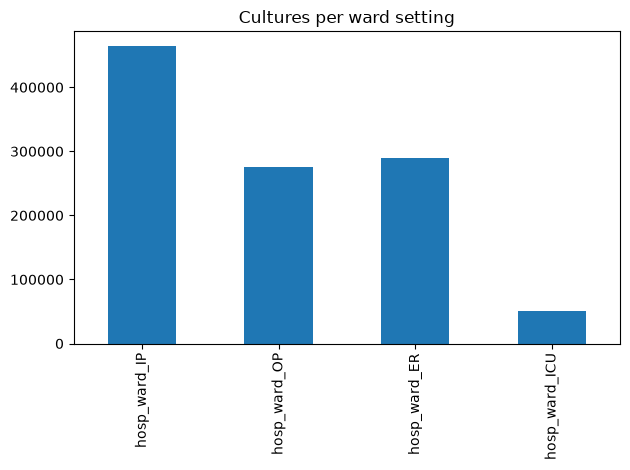

In [10]:
ward = tables.get("ward")
if ward is not None:
    flag_cols = [c for c in ward.columns if c.lower().startswith("hosp_ward")]
    print("ward flag columns:", flag_cols)
    for c in flag_cols:
        print(f"{c}: {int(ward[c].sum()):,} positive")
    if flag_cols:
        ward[flag_cols].sum().plot(kind="bar", title="Cultures per ward setting")
        plt.tight_layout(); plt.show()
else:
    print("ward table not loaded")

## Comorbidity & procedure cardinality (shared node counts)

In [11]:
for key, col in [("comorbidity", "comorbidity_component"), ("procedures", "procedure_name")]:
    df = tables.get(key)
    if df is not None and col in df.columns:
        print(f"{key}: {df[col].nunique()} distinct {col}")
        print(df[col].value_counts().head(10), "\n")

comorbidity: 438 distinct comorbidity_component
comorbidity_component
Neoplasm-related encounters                        1288
Other specified and unspecified skin disorders     1284
Breast cancer - all other types                    1276
Depression                                         1198
Nonspecific chest pain                             1156
Metastatic cancer                                  1136
Fever                                              1100
Diseases of white blood cells                      1094
Leukemia - acute myeloid leukemia (AML)            1086
Rheumatoid arthritis/collagen vascular diseases    1082
Name: count, dtype: int64 



## Notes / next steps

Write down what you found (label balance, ward sizes, null-heavy columns to drop or impute, organism/antibiotic counts). These decisions feed `data_loader.py` and `graph_build.py`.

**Next:** build `src/amr_fed/data_loader.py` to load + join the tables on the four keys, then `graph_build.py` for one ward's heterogeneous graph.